In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

2026-04-16 20:40:03.575720: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [35]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from skimage.exposure import equalize_adapthist
from skimage.filters import gaussian as sk_gaussian
from tqdm import tqdm
import psutil

DIM         = 128
NUM_CLASSES = 2

TRAIN_DIR = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train'
TEST_DIR  = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test'

# ── Load raw data ─────────────────────────────────────────────────────────────
def load_data(data_dir, dim=DIM):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int',
        image_size=(dim, dim),
        batch_size=None,
        shuffle=False
    )
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    return x, y

print('Loading training data...')
x_train_raw, y_train_int = load_data(TRAIN_DIR)
print('Loading test data...')
x_test_raw,  y_test_int  = load_data(TEST_DIR)

n_train, n_test = len(x_train_raw), len(x_test_raw)
print(f'Train: {n_train} | Test: {n_test}')

# Verify class order — Keras sorts alphabetically
class_names = sorted(os.listdir(TRAIN_DIR))
print(f'Class order: {class_names}')  # [NORMAL, PNEUMONIA] -> 0, 1

# ── Grayscale + normalise ─────────────────────────────────────────────────────
def to_gray_norm(images_rgb, N):
    out = np.empty((N, DIM, DIM), dtype=np.float32)
    for i in tqdm(range(N), desc='Grayscale+Norm'):
        gray   = cv2.cvtColor(images_rgb[i].astype(np.uint8),
                               cv2.COLOR_RGB2GRAY)
        out[i] = gray / 255.0
    return out

x_train_gray = to_gray_norm(x_train_raw, n_train)
x_test_gray  = to_gray_norm(x_test_raw,  n_test)
del x_train_raw, x_test_raw

# ── One-hot labels ────────────────────────────────────────────────────────────
y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_int,  num_classes=NUM_CLASSES)

# ── Preprocessing — CLAHE + central crop + smoothing (no segmentation) ────────
def preprocess_xray(img):
    """
    Input : (64, 64) float32 in [0,1] — grayscale, normalised
    Output: (64, 64) float32 in [0,1]
    Steps : CLAHE → fixed central crop → resize → Gaussian smooth → renorm
    """
    # 1. CLAHE
    img = equalize_adapthist(img, clip_limit=0.03).astype(np.float32)
    # 2. Fixed central crop — removes chest wall borders
    h, w  = img.shape
    pad_h = int(h * 0.10)
    pad_w = int(w * 0.08)
    img   = img[pad_h:h-pad_h, pad_w:w-pad_w]
    # 3. Resize back to 64x64
    img = cv2.resize(img, (DIM, DIM), interpolation=cv2.INTER_AREA)
    # 4. Gaussian smoothing
    img = sk_gaussian(img, sigma=0.5).astype(np.float32)
    # 5. Re-normalise
    if img.max() > 1e-8:
        img = img / img.max()
    return img

print('Preprocessing training images...')
x_train = np.zeros((n_train, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_train), desc='Train'):
    x_train[i] = preprocess_xray(x_train_gray[i])

print('Preprocessing test images...')
x_test = np.zeros((n_test, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_test), desc='Test'):
    x_test[i] = preprocess_xray(x_test_gray[i])

del x_train_gray, x_test_gray

# ── Verify class split ────────────────────────────────────────────────────────
N_NORMAL    = int(np.sum(y_train_int == 0))
N_PNEUMONIA = int(np.sum(y_train_int == 1))
print(f'\nNormal    : {N_NORMAL}  (idx 0 to {N_NORMAL-1})')
print(f'Pneumonia : {N_PNEUMONIA}  (idx {N_NORMAL} to {n_train-1})')
print(f'x_train   : {x_train.shape}')
print(f'x_test    : {x_test.shape}')

ram = psutil.virtual_memory()
print(f'RAM available: {ram.available/1e9:.1f} GB')


Loading training data...
Found 5216 files belonging to 2 classes.
Loading test data...
Found 624 files belonging to 2 classes.
Train: 5216 | Test: 624
Class order: ['NORMAL', 'PNEUMONIA']


Grayscale+Norm: 100%|██████████| 624/624 [00:00<00:00, 10871.13it/s]


Preprocessing training images...


Train: 100%|██████████| 5216/5216 [00:16<00:00, 312.56it/s]


Preprocessing test images...


Test: 100%|██████████| 624/624 [00:01<00:00, 333.87it/s]


Normal    : 1341  (idx 0 to 1340)
Pneumonia : 3875  (idx 1341 to 5215)
x_train   : (5216, 128, 128)
x_test    : (624, 128, 128)
RAM available: 10.3 GB


In [36]:
idx_healthy = np.where(y_train_int==0)
healthy = x_train[idx_healthy]

idx_unhealthy = np.where(y_train_int==1)
unhealthy = x_train[idx_unhealthy]

reference_healthy = healthy.mean(axis=0).astype(np.float32)
reference_healthy = (reference_healthy - reference_healthy.min()) / \
                    (reference_healthy.max() - reference_healthy.min() + 1e-8)

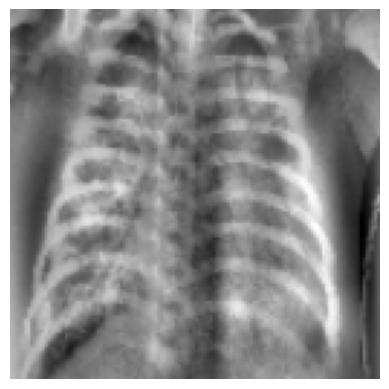

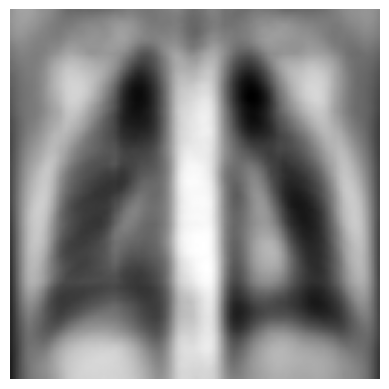

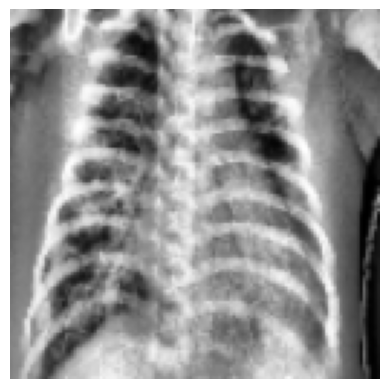

In [56]:
diff = unhealthy[0] - reference_healthy
plt.imshow(diff, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(reference_healthy, cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(unhealthy[0], cmap='gray')
plt.axis('off')
plt.show()

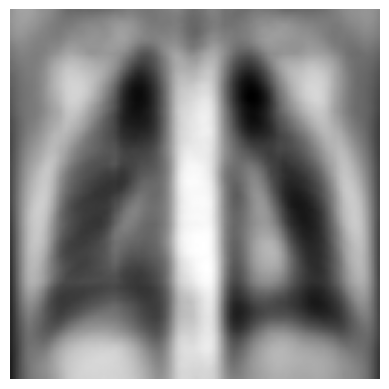

In [57]:
plt.imshow(reference_healthy, cmap='gray')
plt.axis('off')
plt.show()

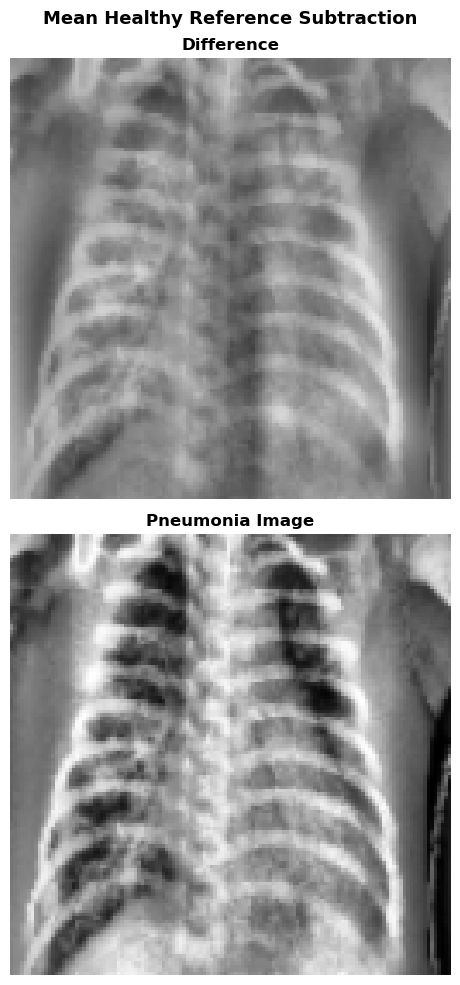

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# ── Build healthy reference ───────────────────────────────────────────────────
y_ints         = np.argmax(y_train, axis=1)
healthy_imgs   = x_train[y_ints == 0]

reference_healthy = healthy_imgs.mean(axis=0).astype(np.float32)
reference_healthy = (reference_healthy - reference_healthy.min()) / \
                    (reference_healthy.max() - reference_healthy.min() + 1e-8)

# ── Pick one pneumonia image ──────────────────────────────────────────────────
pneumonia_idx = np.where(y_ints == 1)[0][0]
img           = x_train[pneumonia_idx].astype(np.float32)

diff     = img - reference_healthy
#diff_abs = np.abs(diff)
#diff_abs = diff_abs / (diff_abs.max() + 1e-8)
vmax     = np.abs(diff).max()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(5, 10))

#axes[0].imshow(reference_healthy, cmap='gray')
#axes[0].set_title('Healthy Reference\n(mean of 1341 normal)', fontweight='bold')
#axes[0].axis('off')

axes[1].imshow(img, cmap='gray')
axes[1].set_title('Pneumonia Image', fontweight='bold')
axes[1].axis('off')

im = axes[0].imshow(diff, cmap='gray', vmin=-1, vmax=1)
axes[0].set_title('Difference', fontweight='bold')
axes[0].axis('off')
#plt.colorbar(im, ax=axes[0:], fraction=0.046)

plt.suptitle('Mean Healthy Reference Subtraction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('reference_subtraction.png', dpi=300, bbox_inches='tight')
plt.show()

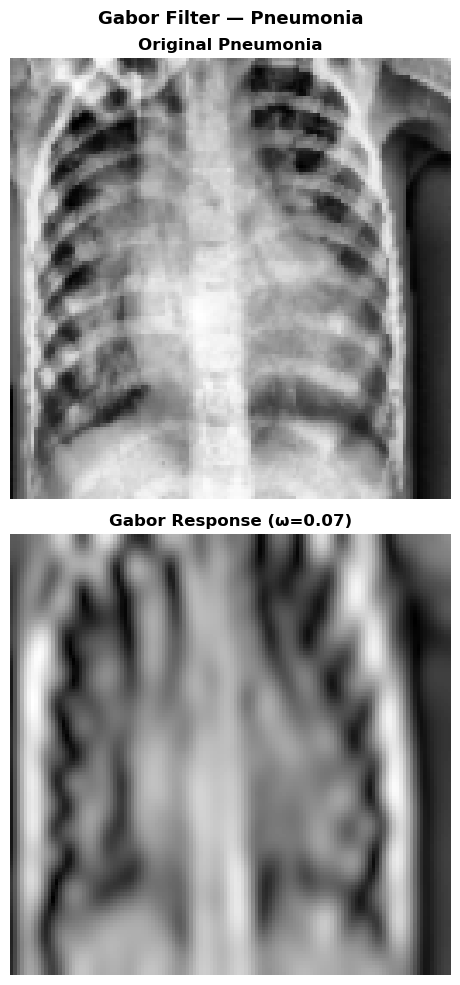

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gabor

# ── Pick one pneumonia image ──────────────────────────────────────────────────
y_ints        = np.argmax(y_train, axis=1)
pneumonia_idx = np.where(y_ints == 1)[0][4]
img           = x_train[pneumonia_idx].astype(np.float32)

# ── Apply Gabor filter ────────────────────────────────────────────────────────
frequency = 0.07   # cycles/pixel — adjust based on power spectrum analysis

real, imag = gabor(img, frequency=frequency, sigma_x=4.0, sigma_y=4.0)
response   = np.sqrt(real.astype(np.float32)**2 +
                      imag.astype(np.float32)**2)
response   = (response - response.min()) / (response.max() - response.min() + 1e-8)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(5, 10))

axes[0].imshow(img,      cmap='gray')
axes[0].set_title('Original Pneumonia', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(response, cmap='gray')
axes[1].set_title(f'Gabor Response (ω={frequency})', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Gabor Filter — Pneumonia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gabor_pneumonia.png', dpi=300, bbox_inches='tight')
plt.show()

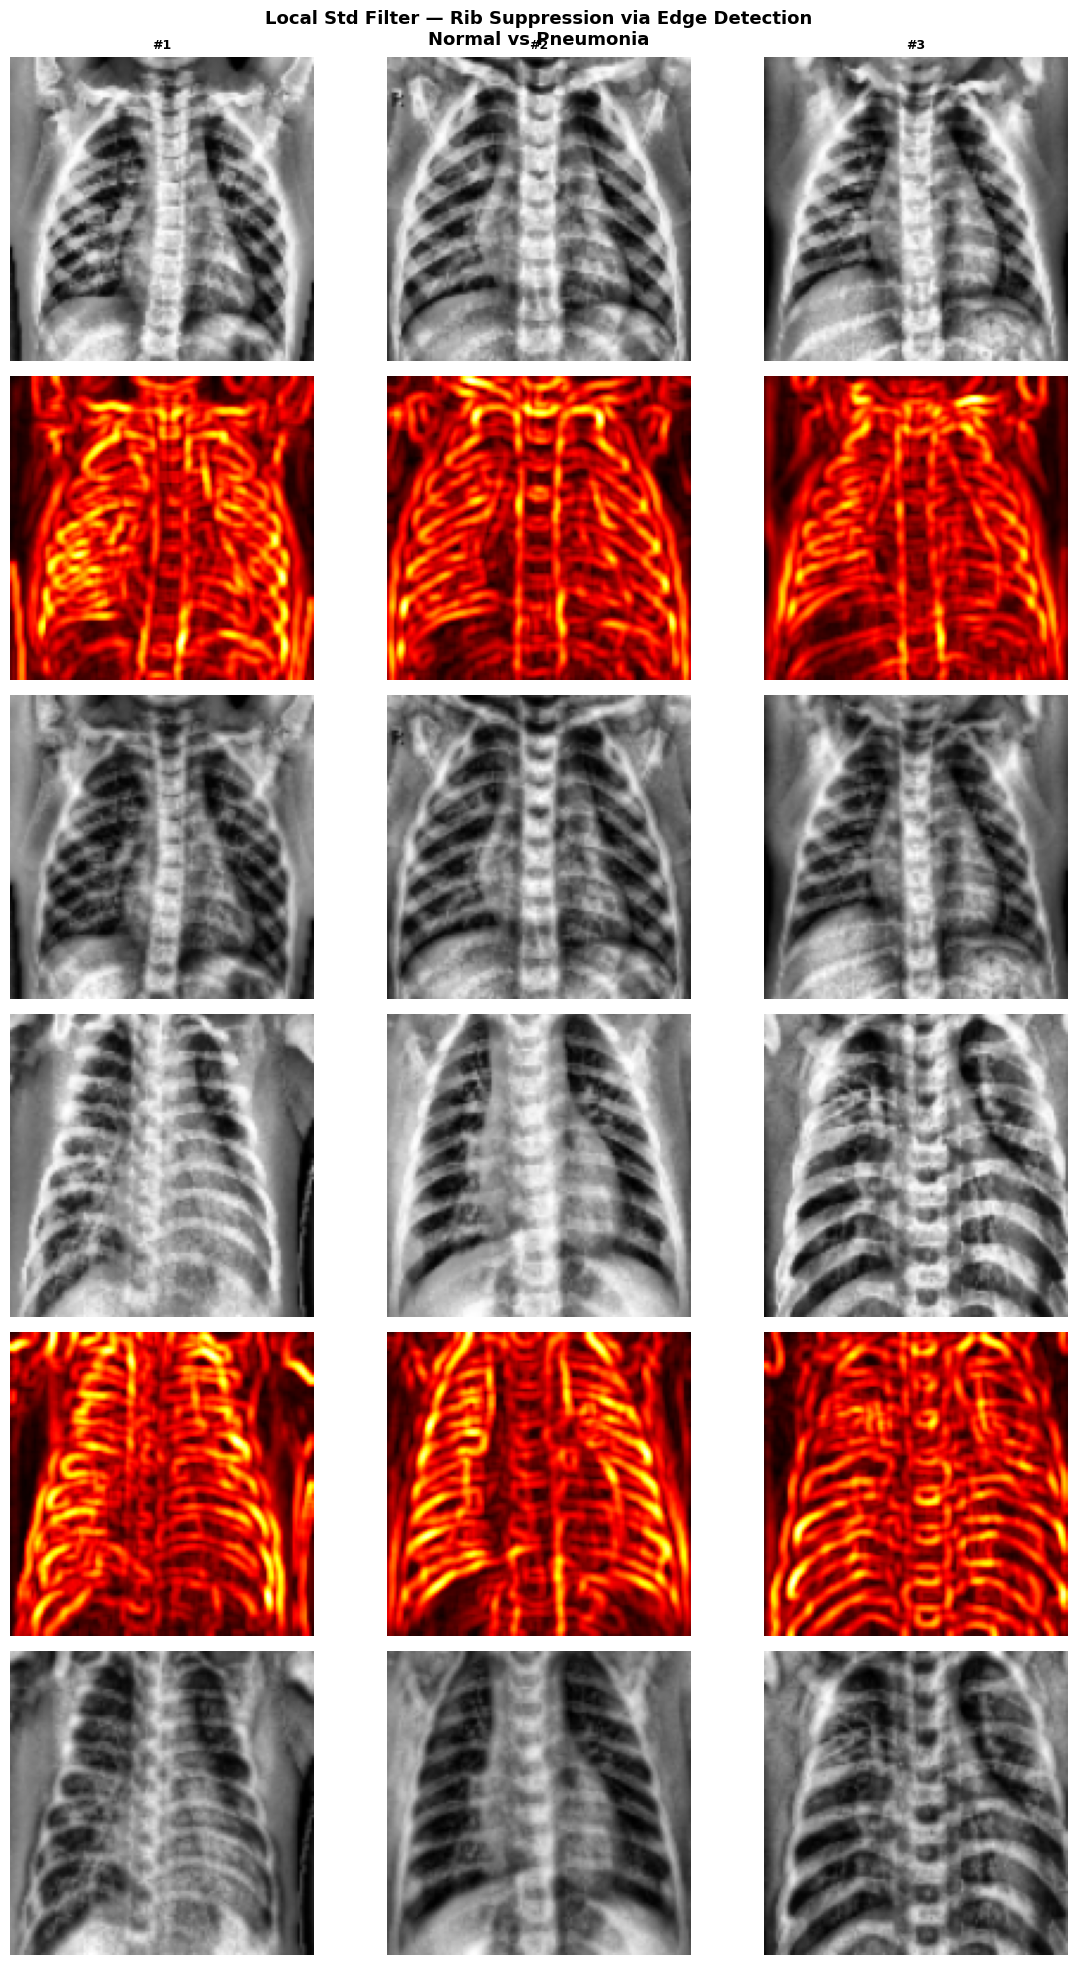

In [49]:
from scipy.ndimage import uniform_filter
import numpy as np

def local_std_mask(image, window=5, threshold=None):
    """
    Computes local standard deviation in a sliding window.
    High values = high contrast neighbourhood = likely rib edge.
    Low values = smooth region = likely parenchyma or consolidation.

    Parameters
    ----------
    image     : (H, W) float32 in [0,1]
    window    : int — neighbourhood size in pixels
                5-9 pixels works well at 128×128
    threshold : float or None — if set, returns binary mask
                pixels with local_std < threshold are kept (smooth regions)

    Returns
    -------
    local_std  : (H, W) float32 — local standard deviation map
    smooth_mask: (H, W) float32 — inverse of local std (smooth regions bright)
    """
    # E[X^2] - E[X]^2 = Var[X]
    mean_sq = uniform_filter(image**2,    size=window)
    sq_mean = uniform_filter(image,       size=window)**2
    local_var = np.clip(mean_sq - sq_mean, 0, None)
    local_std = np.sqrt(local_var).astype(np.float32)

    # Normalise
    s_min = local_std.min(); s_rng = local_std.max() - s_min
    if s_rng > 1e-8:
        local_std_norm = (local_std - s_min) / s_rng
    else:
        local_std_norm = local_std * 0

    # Smooth mask — inverse of local std
    # High local std → low mask value (suppress edges)
    # Low local std  → high mask value (keep smooth regions)
    smooth_mask = 1.0 - local_std_norm

    if threshold is not None:
        smooth_mask = (local_std < threshold).astype(np.float32)

    return local_std_norm, smooth_mask


def apply_smooth_region_filter(image, window=5):
    """
    Suppresses high-contrast edge regions and preserves smooth regions.
    Designed to suppress rib edges while preserving consolidation haze.

    Steps:
    1. Compute local std → identifies high-contrast neighbourhoods
    2. Create smooth mask → 1 where smooth, 0 where edges
    3. Multiply image by smooth mask → suppress edge regions
    4. What remains is predominantly smooth parenchymal content

    Parameters
    ----------
    image  : (H, W) float32 in [0,1]
    window : int — neighbourhood size

    Returns
    -------
    filtered    : (H, W) float32 — edge-suppressed image
    smooth_mask : (H, W) float32 — the suppression mask
    local_std   : (H, W) float32 — local contrast map
    """
    local_std, smooth_mask = local_std_mask(image, window=window)

    # Apply smooth Gaussian taper to mask edges to avoid ringing
    from scipy.ndimage import gaussian_filter
    smooth_mask_tapered = gaussian_filter(smooth_mask, sigma=1.0)

    # Suppress high-contrast regions
    filtered = image * smooth_mask_tapered

    # Renormalise
    f_min = filtered.min(); f_rng = filtered.max() - f_min
    if f_rng > 1e-8:
        filtered = (filtered - f_min) / f_rng

    return filtered.astype(np.float32), smooth_mask_tapered, local_std


# ── Visual check on Normal vs Pneumonia ──────────────────────────────────────
y_ints        = np.argmax(y_train, axis=1)
normal_idx    = np.where(y_ints == 0)[0][:3]
pneumonia_idx = np.where(y_ints == 1)[0][:3]

fig, axes = plt.subplots(6, 3, figsize=(12, 20))

row_labels = ['Normal Original',
              'Normal Local Std',
              'Normal Filtered',
              'Pneumonia Original',
              'Pneumonia Local Std',
              'Pneumonia Filtered']

for col in range(3):
    for group, (idx, label) in enumerate([(normal_idx,    'Normal'),
                                           (pneumonia_idx, 'Pneumonia')]):
        img                           = x_train[idx[col]]
        filtered, smooth_mask, local_std = apply_smooth_region_filter(
                                            img, window=5)
        base = group * 3

        axes[base,     col].imshow(img,       cmap='gray')
        axes[base,     col].axis('off')

        axes[base + 1, col].imshow(local_std, cmap='hot')
        axes[base + 1, col].axis('off')

        axes[base + 2, col].imshow(filtered,  cmap='gray')
        axes[base + 2, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight='bold')

for col in range(3):
    axes[0, col].set_title(f'#{col+1}', fontsize=9, fontweight='bold')

plt.suptitle('Local Std Filter — Rib Suppression via Edge Detection\n'
             'Normal vs Pneumonia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('local_std_filter.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
import numpy as np

def estimate_sigma_from_image(image, percentile=10):
    """
    Estimates Gaussian noise sigma from a single image using the
    low-intensity background region.
    """
    threshold         = np.percentile(image, percentile)
    background_pixels = image[image <= threshold]
    if len(background_pixels) < 10:
        return float(np.std(image))
    sigma = float(np.std(background_pixels))
    return max(sigma, 1e-8)


def compute_single_pair_fi_heatmap(image1, image2):
    """
    Computes the pairwise Gaussian Fisher Information heatmap between
    two individual images from different classes.

    Under the Gaussian noise model (high-SNR limit of Rician):
        FI(i,j) = (M1(i,j) - M2(i,j))^2 / (sigma1^2 + sigma2^2)

    After normalisation sigma cancels — reduces to normalised squared
    pixel difference.

    Parameters
    ----------
    image1 : (H, W) — image from class 1 (No_Tumor)
    image2 : (H, W) — image from class 2 (tumor class)

    Returns
    -------
    fi_map : (H, W) pairwise FI heatmap, normalised to [0, 1]
    """
    sigma1      = estimate_sigma_from_image(image1)
    sigma2      = estimate_sigma_from_image(image2)
    numerator   = (image1.astype(np.float32) - image2.astype(np.float32))**2
    denominator = sigma1**2 + sigma2**2 + 1e-10
    fi_map      = numerator / denominator
    fi_max      = fi_map.max()
    if fi_max > 1e-10:
        fi_map = fi_map / fi_max
    return fi_map.astype(np.float32)


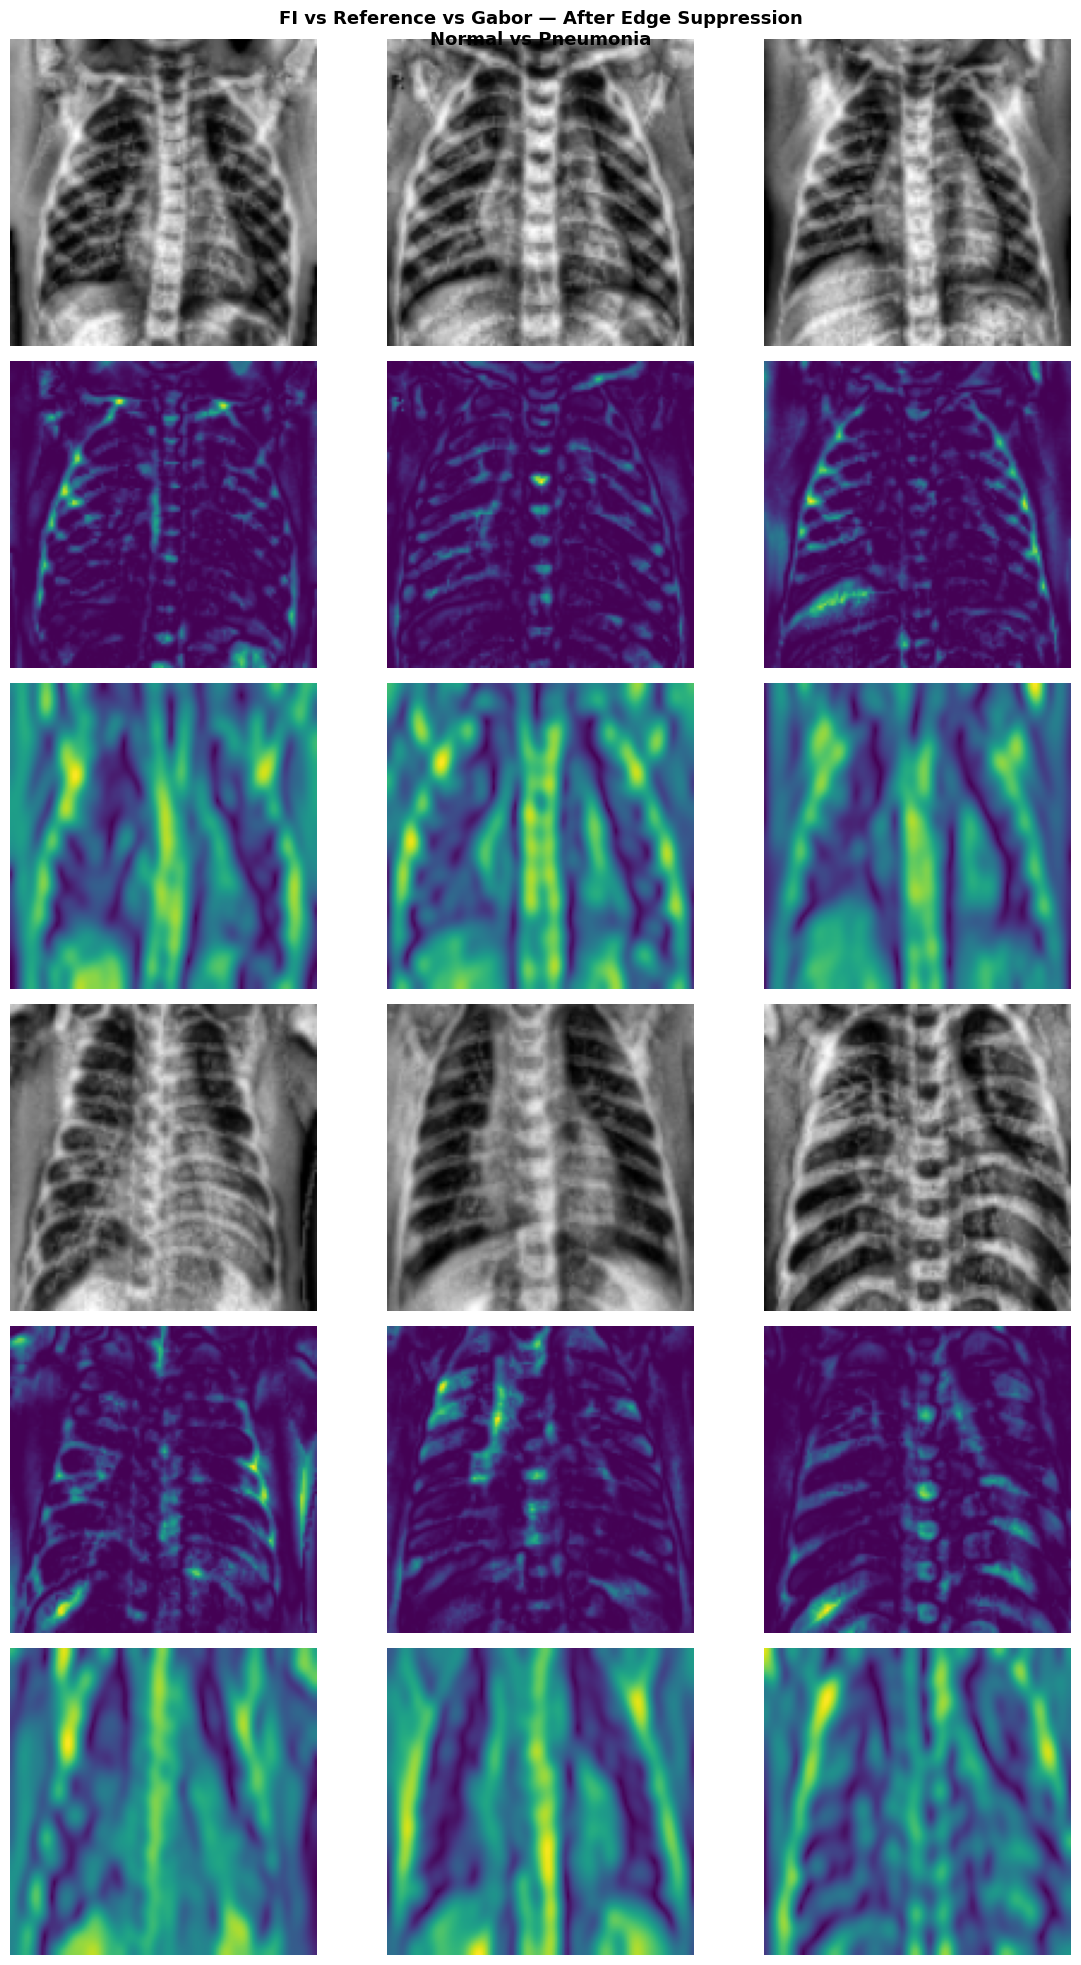

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gabor

y_ints        = np.argmax(y_train, axis=1)
normal_idx    = np.where(y_ints == 0)[0][:3]
pneumonia_idx = np.where(y_ints == 1)[0][:3]

# Build healthy reference from edge-suppressed images
healthy_imgs_filtered = np.array([
    apply_smooth_region_filter(x_train[i], window=5)[0]
    for i in np.where(y_ints == 0)[0]
], dtype=np.float32)

healthy_ref = healthy_imgs_filtered.mean(axis=0)
healthy_ref = (healthy_ref - healthy_ref.min()) / \
              (healthy_ref.max() - healthy_ref.min() + 1e-8)

fig, axes = plt.subplots(6, 3, figsize=(12, 20))

row_labels = ['Normal — edge suppressed',
              'Normal — FI vs reference',
              'Normal — Gabor response',
              'Pneumonia — edge suppressed',
              'Pneumonia — FI vs reference',
              'Pneumonia — Gabor response']

for col in range(3):
    for group, (idx, label) in enumerate([(normal_idx,    'Normal'),
                                           (pneumonia_idx, 'Pneumonia')]):
        img                              = x_train[idx[col]]
        filtered, smooth_mask, local_std = apply_smooth_region_filter(
                                            img, window=5)
        base = group * 3

        # Edge suppressed
        axes[base, col].imshow(filtered, cmap='gray')
        axes[base, col].axis('off')

        # FI vs reference
        sigma_test = estimate_sigma_from_image(filtered)
        sigma_ref  = estimate_sigma_from_image(healthy_ref)
        fi_map     = (filtered - healthy_ref)**2 / \
                     (sigma_test**2 + sigma_ref**2 + 1e-10)
        fi_map     = fi_map / (fi_map.max() + 1e-10)
        axes[base + 1, col].imshow(fi_map, cmap='viridis')
        axes[base + 1, col].axis('off')

        # Gabor on edge-suppressed
        real, imag = gabor(filtered, frequency=0.07,
                            sigma_x=4.0, sigma_y=4.0)
        gabor_resp = np.sqrt(real.astype(np.float32)**2 +
                              imag.astype(np.float32)**2)
        gabor_resp = (gabor_resp - gabor_resp.min()) / \
                     (gabor_resp.max() - gabor_resp.min() + 1e-8)
        axes[base + 2, col].imshow(gabor_resp, cmap='viridis')
        axes[base + 2, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight='bold')

plt.suptitle('FI vs Reference vs Gabor — After Edge Suppression\n'
             'Normal vs Pneumonia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fi_vs_gabor_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Quantitative comparison
for name, maps_n, maps_p in [
    ('FI vs reference', 'fi_normal', 'fi_pneumonia'),
    ('Gabor response',  'gabor_normal', 'gabor_pneumonia')
]:
    pass  # replace with actual arrays once computed above